# Лабораторная работа 4

Вариант 3. ScrapingCourse содержит 147 товаров. Для набора нужного объёма добавлен ScrapingSandbox.

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt

subprocess.run([sys.executable, 'collect.py', '--mode', 'diagnose'], check=True)
subprocess.run([sys.executable, 'collect.py'], check=True)

CompletedProcess(args=['D:\\ПГНИУ\\2course1sem\\dataMining\\.lab-runtime\\venv\\Scripts\\python.exe', 'collect.py'], returncode=0)

## Диагностика

Исходный HTML содержит только первую порцию товаров. С отключённым JS прокрутка не добавляет записи.

In [2]:
diagnostics = json.loads(Path('artifacts/diagnostics.json').read_text(encoding='utf-8'))
display(pd.DataFrame(diagnostics).T[['html_bytes', 'static_records', 'no_js_before_scroll', 'no_js_after_scroll']])

,html_bytes,static_records,no_js_before_scroll,no_js_after_scroll
scrapingcourse,18998,12,12,12
scrapingsandbox,122371,20,20,20


## Сверка способов сбора

In [3]:
browser = pd.read_csv('data_browser.csv')
light = pd.read_csv('data_light.csv')
comparison = json.loads(Path('comparison.json').read_text(encoding='utf-8'))
assert len(browser) >= 200
assert comparison['mismatches'] == 0
assert browser['key'].is_unique
display(browser.head())
display(browser.groupby('source').size().rename('Записей'))
print(comparison)

,key,source,sku,title,price,currency,url,category,image_url
0,scrapingcourse:chaz-kangeroo-hoodie,scrapingcourse,chaz-kangeroo-hoodie,Chaz Kangeroo Hoodie,52.0,USD,https://scrapingcourse.com/ecommerce/product/c...,NaN,https://scrapingcourse.com/ecommerce/wp-conten...
1,scrapingcourse:teton-pullover-hoodie,scrapingcourse,teton-pullover-hoodie,Teton Pullover Hoodie,70.0,USD,https://scrapingcourse.com/ecommerce/product/t...,NaN,https://scrapingcourse.com/ecommerce/wp-conten...
2,scrapingcourse:bruno-compete-hoodie,scrapingcourse,bruno-compete-hoodie,Bruno Compete Hoodie,63.0,USD,https://scrapingcourse.com/ecommerce/product/b...,NaN,https://scrapingcourse.com/ecommerce/wp-conten...
3,scrapingcourse:frankie--sweatshirt,scrapingcourse,frankie--sweatshirt,Frankie Sweatshirt,60.0,USD,https://scrapingcourse.com/ecommerce/product/f...,NaN,https://scrapingcourse.com/ecommerce/wp-conten...
4,scrapingcourse:hollister-backyard-sweatshirt,scrapingcourse,hollister-backyard-sweatshirt,Hollister Backyard Sweatshirt,52.0,USD,https://scrapingcourse.com/ecommerce/product/h...,NaN,https://scrapingcourse.com/ecommerce/wp-conten...


source
scrapingcourse     147
scrapingsandbox    200
Name: Записей, dtype: int64

{'browser_rows': 347, 'light_rows': 347, 'mismatches': 0, 'fields': ['key', 'title', 'price', 'url']}


## Время и объём ответов

Для ScrapingCourse облегчённый способ обращается к XHR-эндпоинту. Для ScrapingSandbox используется браузер с блокировкой медиа, поскольку новые товары не приходят отдельным XHR.

,Способ,"Время, с","Ответы, МБ",Запросы
0,Браузер,57.0886,1.460529,246
1,Облегчённый,26.8979,0.712645,39


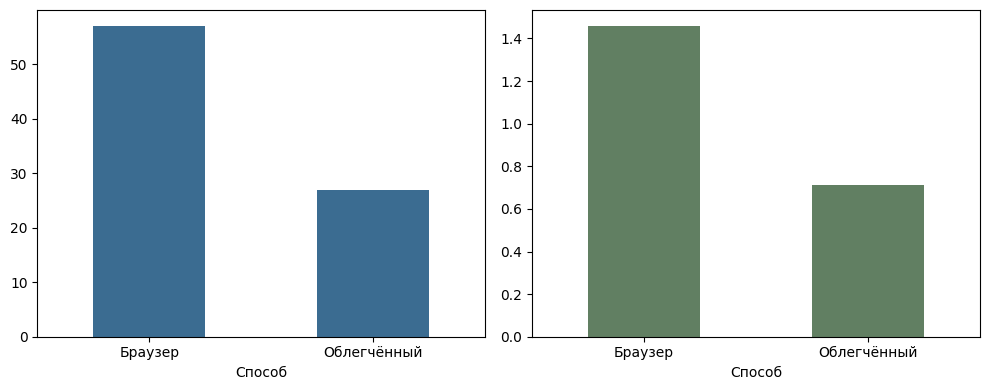

,Источник,sample_elements,per_element_s,bulk_sample_s,speedup
0,scrapingcourse,50,0.236862,0.006040,39.21
1,scrapingsandbox,50,0.386508,0.008193,47.18


In [4]:
baseline = json.loads(Path('metrics_browser.json').read_text(encoding='utf-8'))
optimized = json.loads(Path('metrics_light.json').read_text(encoding='utf-8'))
measurements = pd.DataFrame([{'Способ': name, 'Время, с': sum(x['duration_s'] for x in values), 'Ответы, МБ': sum(x['response_bytes'] for x in values)/1024**2, 'Запросы': sum(x['requests'] for x in values)} for name, values in [('Браузер', baseline), ('Облегчённый', optimized)]])
display(measurements)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
measurements.plot.bar(x='Способ', y='Время, с', legend=False, ax=axes[0], color='#3b6c91')
measurements.plot.bar(x='Способ', y='Ответы, МБ', legend=False, ax=axes[1], color='#617f62')
for axis in axes:
    axis.tick_params(axis='x', rotation=0)
fig.tight_layout()
Path('figures').mkdir(exist_ok=True)
fig.savefig('figures/comparison.png', dpi=160)
plt.show()
display(pd.DataFrame([{'Источник': x['source'], **x['extraction_benchmark']} for x in baseline]))

## n8n и качество данных

In [5]:
nocode = pd.read_csv('nocode/nocode_result.csv')
joined = nocode.merge(browser[['key', 'title', 'price', 'url']], on='key', suffixes=('_n8n', '_python'), validate='one_to_one')
assert len(nocode) >= 20
assert len(joined) == len(nocode)
for name in ['title', 'price', 'url']:
    assert joined[name+'_n8n'].eq(joined[name+'_python']).all()
quality = json.loads(Path('quality_browser.json').read_text(encoding='utf-8'))
assert quality['smoke_ok']
display(nocode.head())
print('Пустых обязательных полей:', quality['empty_required_share'])

,key,title,price,currency,url
0,scrapingsandbox:SKU-HEA-0001,Lightweight Probiotics,155.62,USD,https://scrapingsandbox.com/product/1
1,scrapingsandbox:SKU-ELE-0002,Wireless LED Desk Lamp,145.40,USD,https://scrapingsandbox.com/product/2
2,scrapingsandbox:SKU-FOO-0003,Deluxe Tea Collection,185.01,USD,https://scrapingsandbox.com/product/3
3,scrapingsandbox:SKU-AUT-0004,Essential Tire Gauge,70.86,USD,https://scrapingsandbox.com/product/4
4,scrapingsandbox:SKU-ART-0005,Smart Carving Tools,97.13,USD,https://scrapingsandbox.com/product/5


Пустых обязательных полей: 0.0
